# Evaluation metrics for classification model
Python code to Calculate evaluation metrics for a classification model using confusion matrix.

    - Sensitivity or recall, or true positive rate = correct positive classifications / real total positive = TP / TP + FN
```math
\frac{TP}{TP + FN}
```
    - Specificity or False positive rate = correct negative classifications / real total negative = TN / TN + FP
```math
\frac{TN}{TN + FP}
```
    - Accuracy = correct classifications / total classifications = TP + TN / N
```math
\frac{TP + TN}{N}
```
    - Precision = correct positive classifications / total positive classifications = TP / TP + FP 
```math
\frac{TP}{TP + FP}
```
    - F-Score = 2 * (Precision * Sensitivity) / (Precision + Sensitivity)
```math
2*\frac{Precision * Sensitivity}{Precision + Sensitivity} = 2*\frac{\frac{TP}{TP + FP} * \frac{TP}{TP + FN}}{\frac{TP}{TP + FP} + \frac{TP}{TP + FN}}
```

In [8]:
import tensorflow as tf
from keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, Activation

In [9]:
tf.__version__

'2.20.0'

In [10]:
%load_ext tensorboard
logdir = 'log'

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


## Load Data

In [11]:
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

In [12]:
train_images = train_images.reshape((60000, 28 , 28, 1))
test_images = test_images.reshape((10000, 28 , 28, 1))
# normalize data
train_images = train_images / 255.0
test_images = test_images / 255.0
# Define classes
categories = [0,1,2,3,4,5,6,7,8,9]
# count the number of classes
num_classes = len(categories)

## Define Base Model

In [13]:
# build the network
model = Sequential()
print("Input dimensions: ",train_images.shape[1:])

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=train_images.shape[1:]))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
# model.add(Dropout(0.25))
model.add(Conv2D(64, (3, 3), activation='relu'))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

model.summary()

Input dimensions:  (28, 28, 1)


c:\Users\Diogenes\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

## Train / Fit

In [14]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)

# compile the model to use sparse categorical cross-entropy loss function and adam optimizer
model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(
    x = train_images, 
    y = train_labels,
    #batch_size=128,
    epochs=5,                    
    validation_data=(test_images, test_labels)
    )

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9564 - loss: 0.1421 - val_accuracy: 0.9776 - val_loss: 0.0661
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9853 - loss: 0.0468 - val_accuracy: 0.9882 - val_loss: 0.0361
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9891 - loss: 0.0339 - val_accuracy: 0.9879 - val_loss: 0.0343
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9921 - loss: 0.0248 - val_accuracy: 0.9904 - val_loss: 0.0358
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9935 - loss: 0.0197 - val_accuracy: 0.9871 - val_loss: 0.0457


#### Examine the loss and accuracy metric plots - First training a neural net from scratch
Let's plot the validation loss and validation accuracy over time.

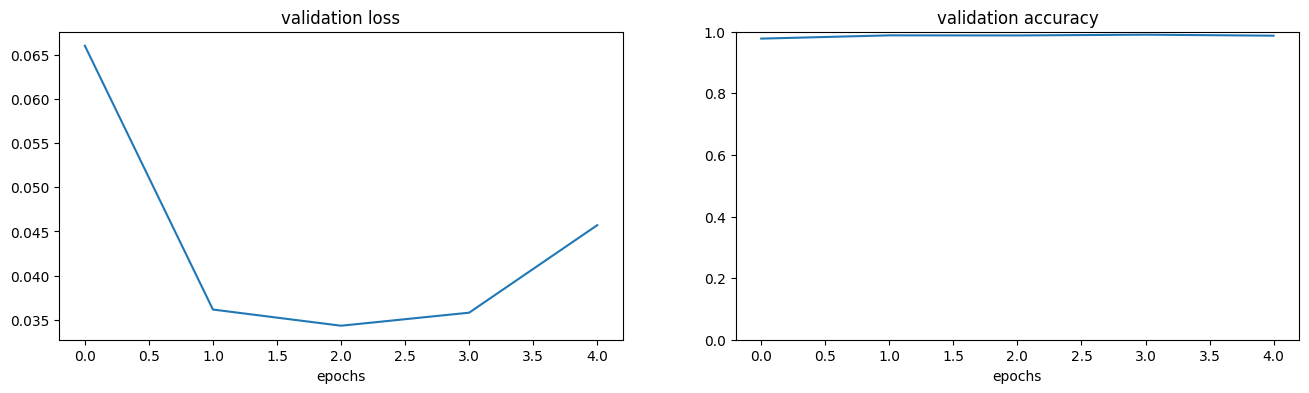

In [15]:
fig = plt.figure(figsize=(16,4))
ax = fig.add_subplot(121)
ax.plot(history.history["val_loss"])
ax.set_title("validation loss")
ax.set_xlabel("epochs")

ax2 = fig.add_subplot(122)
ax2.plot(history.history["val_accuracy"])
ax2.set_title("validation accuracy")
ax2.set_xlabel("epochs")
ax2.set_ylim(0, 1)

plt.show()

In [21]:
loss, accuracy = model.evaluate(test_images, test_labels, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', accuracy)

Test loss: 0.04571159929037094
Test accuracy: 0.9871000051498413


In [24]:
y_true = test_labels
#model.predict_classes was deprecated and removed
y_pred = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


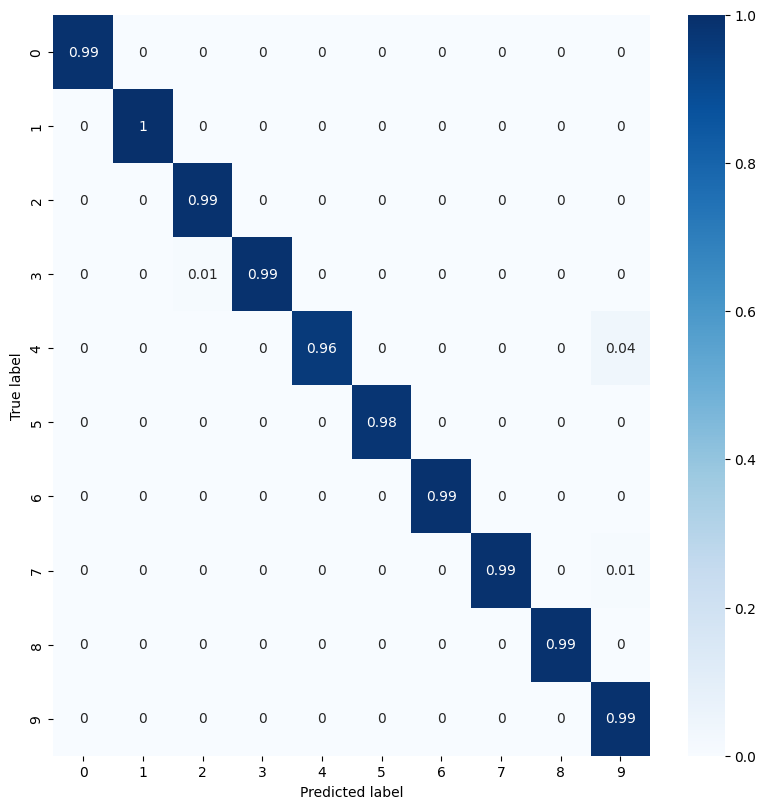

In [40]:
# Transform class scores to predictions
y_pred_2 = y_pred.argmax(axis = 1)

confusion_mat = tf.math.confusion_matrix(labels=y_true, predictions=y_pred_2 , num_classes=num_classes).numpy()
confusion_mat_norm = np.around(confusion_mat.astype('float') / confusion_mat.sum(axis = 1)[:,np.newaxis],decimals = 2)
confusion_mat_df = pd.DataFrame(confusion_mat_norm, index = categories, columns = categories)

figure = plt.figure(figsize = (8, 8))
sns.heatmap(confusion_mat_df, annot = True, cmap = plt.cm.Blues)
plt.tight_layout()
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

Confusion Matrix:
[[ 974    1    1    0    0    0    3    1    0    0]
 [   0 1135    0    0    0    0    0    0    0    0]
 [   0    5 1025    1    0    0    0    1    0    0]
 [   2    0    6  995    0    2    0    5    0    0]
 [   0    1    0    0  938    0    3    0    3   37]
 [   3    1    0    4    0  878    2    1    0    3]
 [   2    2    0    0    0    2  952    0    0    0]
 [   0    4    2    0    0    0    0 1015    1    6]
 [   4    1    3    0    0    0    1    1  961    3]
 [   0    2    0    0    1    1    0    5    2  998]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.96      0.98       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99     

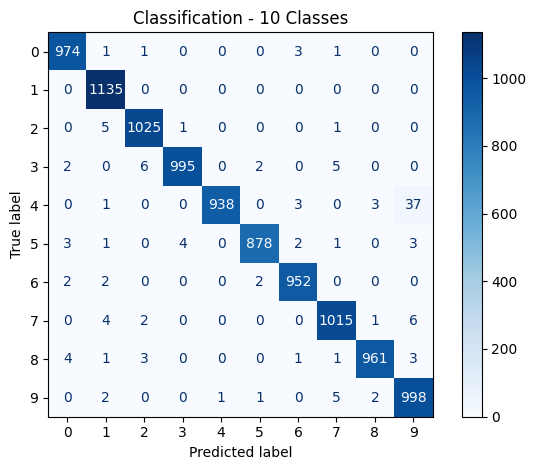

In [38]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Transform class scores to predictions
y_pred_2 = y_pred.argmax(axis = 1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_2)
print("Confusion Matrix:")
print(cm)
 
# Classification report
print("\nClassification Report:")
print(classification_report(
    y_true, y_pred_2
))
 
# Visualize
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=categories
)
disp.plot(cmap='Blues')
plt.title('Classification - 10 Classes')
plt.tight_layout()
plt.savefig('multi_class_confusion_matrix.png', dpi=150)
plt.show()